In [26]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [27]:
clean_df = pd.read_csv("../../data/clean_numeric_pattern.csv")
X_std_scaled = pd.read_csv("../../data/standard_scaler.csv")

X = X_std_scaled
y = clean_df["Target"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 10)
Testing data: (1001, 10)


In [29]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
linear_predictions = linear_model.predict(X_test)

In [31]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [32]:
tree_predictions = tree_model.predict(X_test)

In [33]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
forest_predictions = forest_model.predict(X_test)

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [36]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):
    
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

In [37]:
results = [
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    ),

    evaluate_model(
        "Decision Tree",
        y_test,
        tree_predictions
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        forest_predictions
    )
]

results_df = pd.DataFrame(results)

display(results_df)

,Model,MAE,RMSE,R²
0,Linear Regression,23.387058,29.710426,0.952716
1,Decision Tree,35.009872,44.598567,0.893454
2,Random Forest,20.623515,27.283760,0.960125


In [38]:
import matplotlib.pyplot as plt

In [39]:
def actual_vs_predicted(
    y_true,
    y_pred,
    model_name
):
    
    plt.figure(figsize=(8, 8))
    
    plt.scatter(
        y_true,
        y_pred,
        alpha=0.6
    )
    
    min_value = min(
        y_true.min(),
        y_pred.min()
    )
    
    max_value = max(
        y_true.max(),
        y_pred.max()
    )
    
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )
    
    plt.xlabel("Actual Target")
    plt.ylabel("Predicted Target")
    plt.title(
        f"{model_name} - Actual vs Predicted"
    )
    
    plt.tight_layout()
    plt.show()

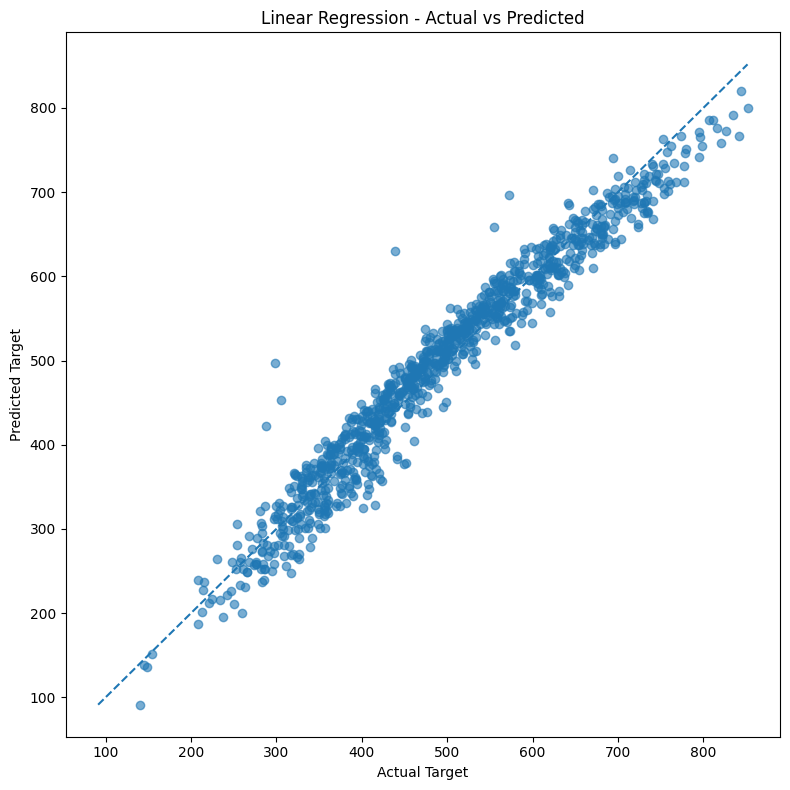

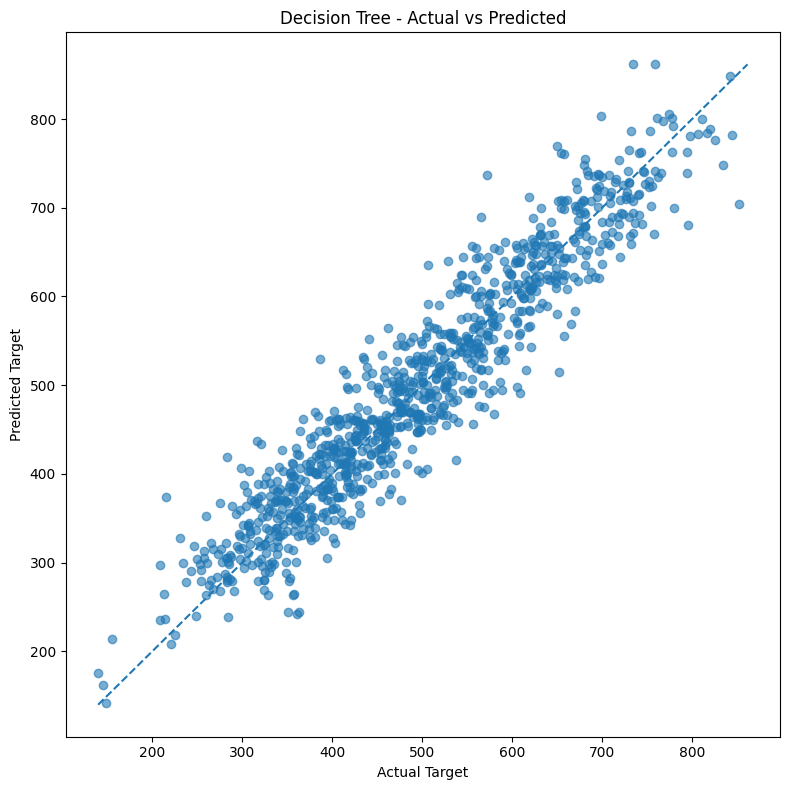

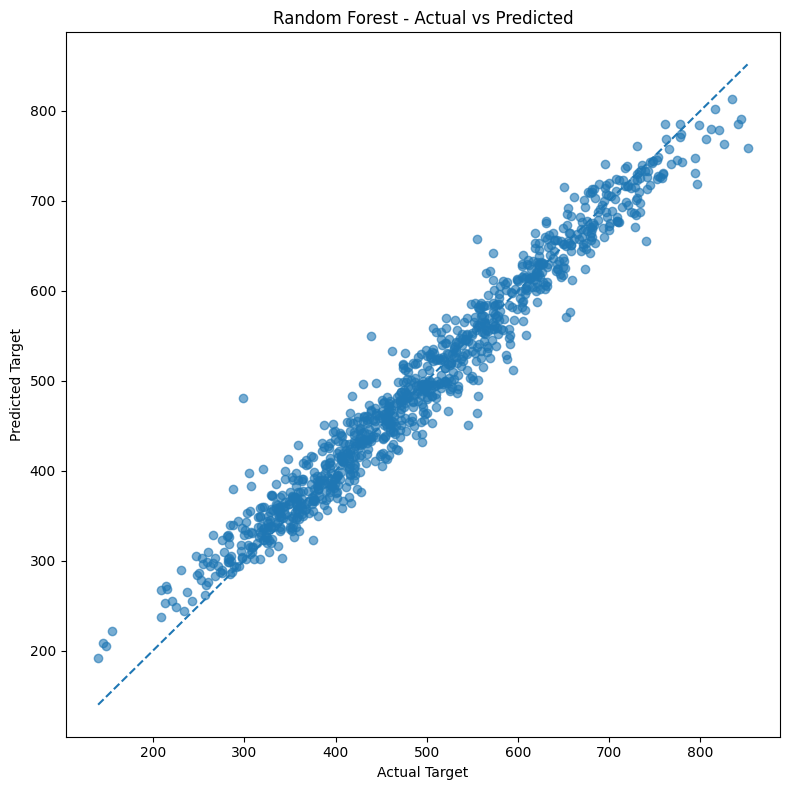

In [40]:
actual_vs_predicted(
    y_test,
    linear_predictions,
    "Linear Regression"
)

actual_vs_predicted(
    y_test,
    tree_predictions,
    "Decision Tree"
)

actual_vs_predicted(
    y_test,
    forest_predictions,
    "Random Forest"
)

In [41]:
def residual_plot(
    y_true,
    y_pred,
    model_name
):
    
    residuals = y_true - y_pred
    
    plt.figure(figsize=(10, 6))
    
    plt.scatter(
        y_pred,
        residuals,
        alpha=0.6
    )
    
    plt.axhline(
        y=0,
        linestyle="--"
    )
    
    plt.xlabel("Predicted Target")
    plt.ylabel("Residual")
    plt.title(
        f"{model_name} - Residual Plot"
    )
    
    plt.tight_layout()
    plt.show()

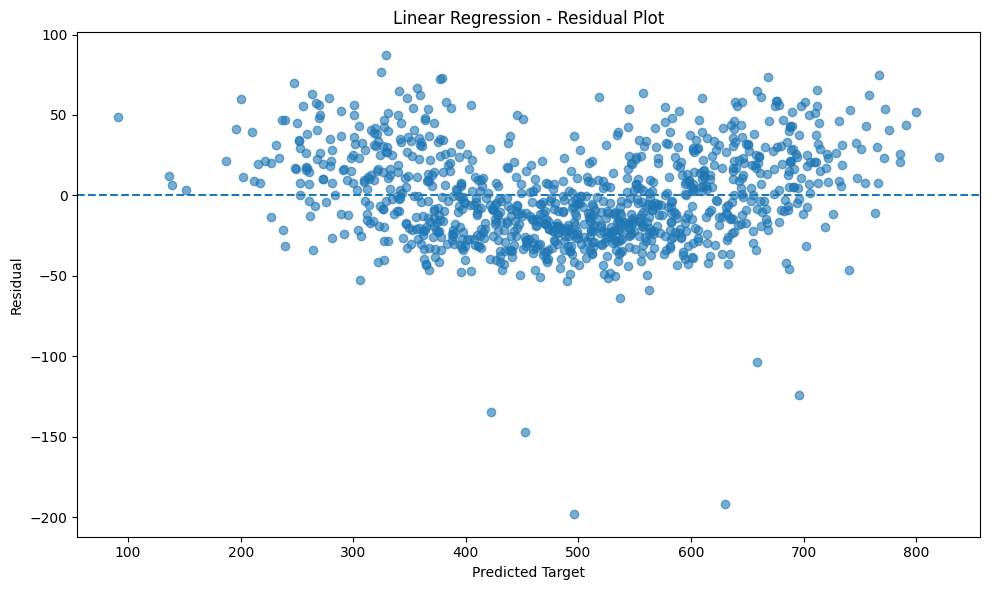

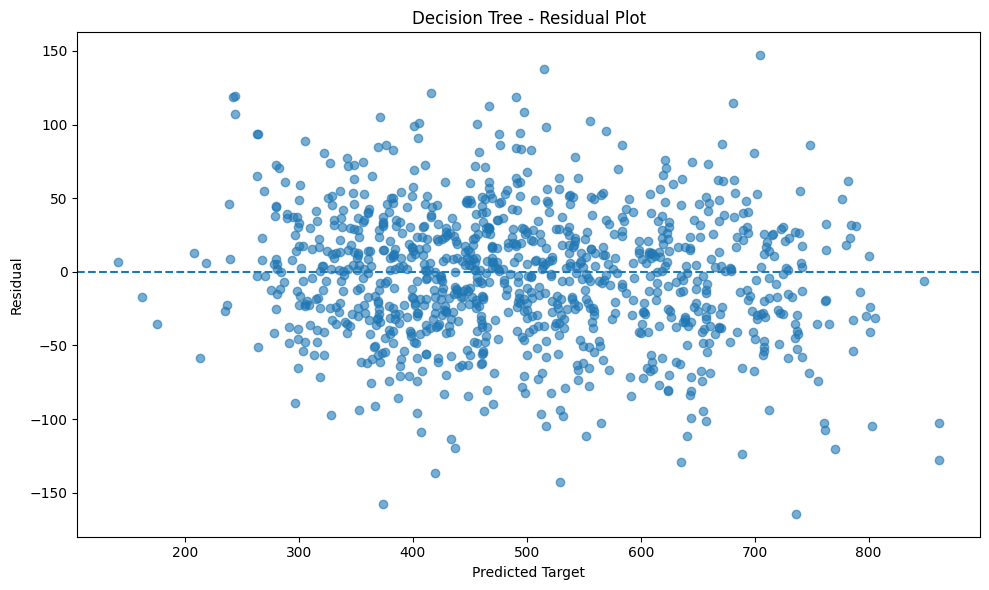

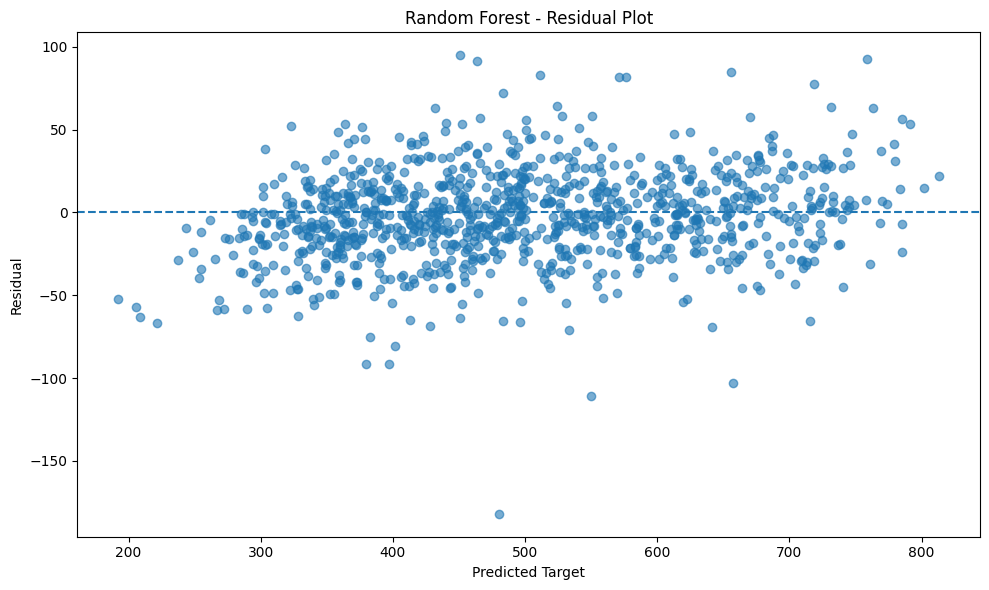

In [42]:
residual_plot(
    y_test,
    linear_predictions,
    "Linear Regression"
)

residual_plot(
    y_test,
    tree_predictions,
    "Decision Tree"
)

residual_plot(
    y_test,
    forest_predictions,
    "Random Forest"
)

In [43]:
from sklearn.svm import SVR

In [45]:
svr_model = SVR(
    kernel="rbf"
)

svr_model.fit(X_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [46]:
svr_predictions = svr_model.predict(X_test)

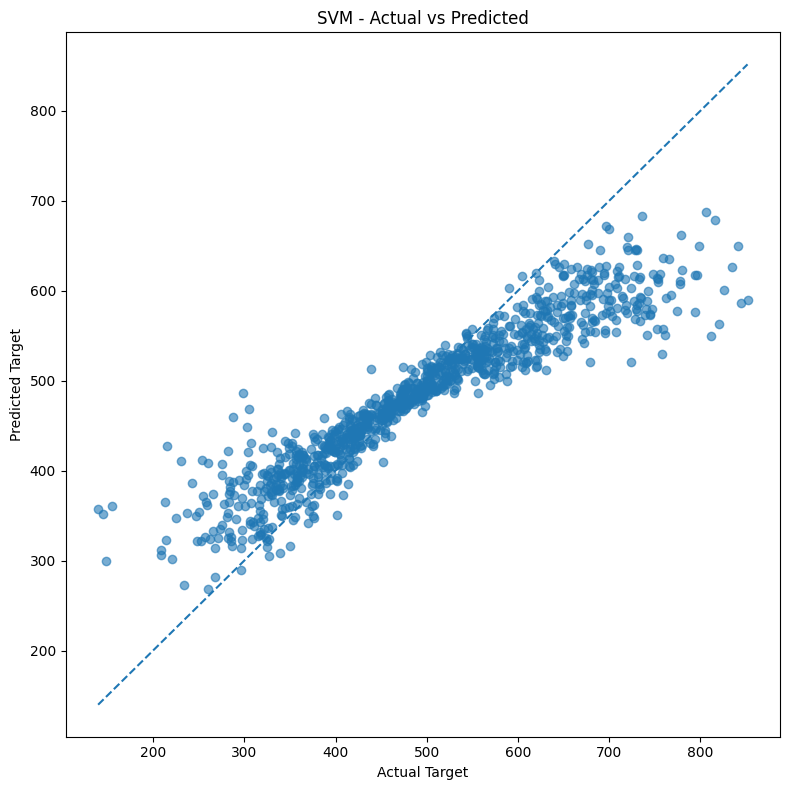

SVR
MAE : 48.132078520631296
RMSE: 66.95647293796101
R²  : 0.7598512237441342


In [50]:
svr_mae = mean_absolute_error(
    y_test,
    svr_predictions
)

svr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        svr_predictions
    )
)

svr_r2 = r2_score(
    y_test,
    svr_predictions
)

actual_vs_predicted(
    y_test,
    svr_predictions,
    "SVM"
)

print("SVR")
print("MAE :", svr_mae)
print("RMSE:", svr_rmse)
print("R²  :", svr_r2)

In [49]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "SVR"
    ],
    "R²": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, tree_predictions),
        r2_score(y_test, forest_predictions),
        svr_r2
    ],
    "Model Parameters": [
        "Default",
        "random_state=42",
        "n_estimators=100",
        "kernel='rbf'"
    ]
})

display(model_comparison)

,Model,R²,Model Parameters
0,Linear Regression,0.952716,Default
1,Decision Tree,0.893454,random_state=42
2,Random Forest,0.960125,n_estimators=100
3,SVR,0.759851,kernel='rbf'
